# Milestone 2: Data Analysis and Visualization
## Objectives:
• Perform in-depth data analysis and generate insights through visualizations to aid in healthcare
decision-making.




In the previous stage, we focused on cleaning and preparing the data. We handled missing information, removed any duplicate records, and used statistical methods to fix outliers. We also converted categories into numbers and used feature scaling to make sure all numerical data is on the same scale.

At this point, the dataset is fully cleaned and ready for in-depth data analysis and visualization.

## 2. Data Analysis:

### Importing Required Libraries
*   **Pandas** — Used for loading, cleaning, and organizing data into DataFrames.
*   **NumPy** — Used for numerical computations and array operations.
*   **Matplotlib** — Used for creating static charts and visualizations.
*   **Seaborn** — Used for creating styled statistical visualizations and heatmaps.
*   **Scipy** — Used for statistical tests like Chi-Square and T-Test.
*   **Scikit-learn** — Used for machine learning tools like feature importance and data scaling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import pointbiserialr, chi2_contingency, ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

### Reading the Cleaned dataset and explore it

In [4]:
# from google.colab import files
# uploaded = files.upload()

In [5]:
df = pd.read_csv(r"C:\Users\Abdelrahman\OneDrive\Documents\DEPI\Final_Project_DEPI\Milestone_2\Cleaned_data.csv")
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404137 entries, 0 to 404136
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      404137 non-null  object 
 1   Sex                        404137 non-null  object 
 2   GeneralHealth              404137 non-null  object 
 3   PhysicalHealthDays         404137 non-null  float64
 4   MentalHealthDays           404137 non-null  float64
 5   LastCheckupTime            404137 non-null  object 
 6   PhysicalActivities         404137 non-null  int64  
 7   SleepHours                 404137 non-null  float64
 8   RemovedTeeth               404137 non-null  object 
 9   HadHeartAttack             404137 non-null  int64  
 10  HadAngina                  404137 non-null  int64  
 11  HadStroke                  404137 non-null  int64  
 12  HadAsthma                  404137 non-null  int64  
 13  HadSkinCancer

In [6]:
print('\nFirst 5 rows of the DataFrame:')
df.head()


First 5 rows of the DataFrame:


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,1,9.0,None of them,0,...,1.60,71.67,3.367161,0,0,1,1,"Yes, received Tdap",0,0
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,1,6.0,None of them,0,...,1.78,95.25,3.436001,0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
2,Alabama,Male,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,0,8.0,1 to 5,0,...,1.83,88.45,3.310968,0,0,0,0,"No, did not receive any tetanus shot in the pa...",0,0
3,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,0,8.0,"6 or more, but not all",0,...,1.85,108.86,3.490647,1,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
4,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,1,9.0,None of them,0,...,1.70,90.72,3.477881,0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,1


### 1. Correlation Analysis


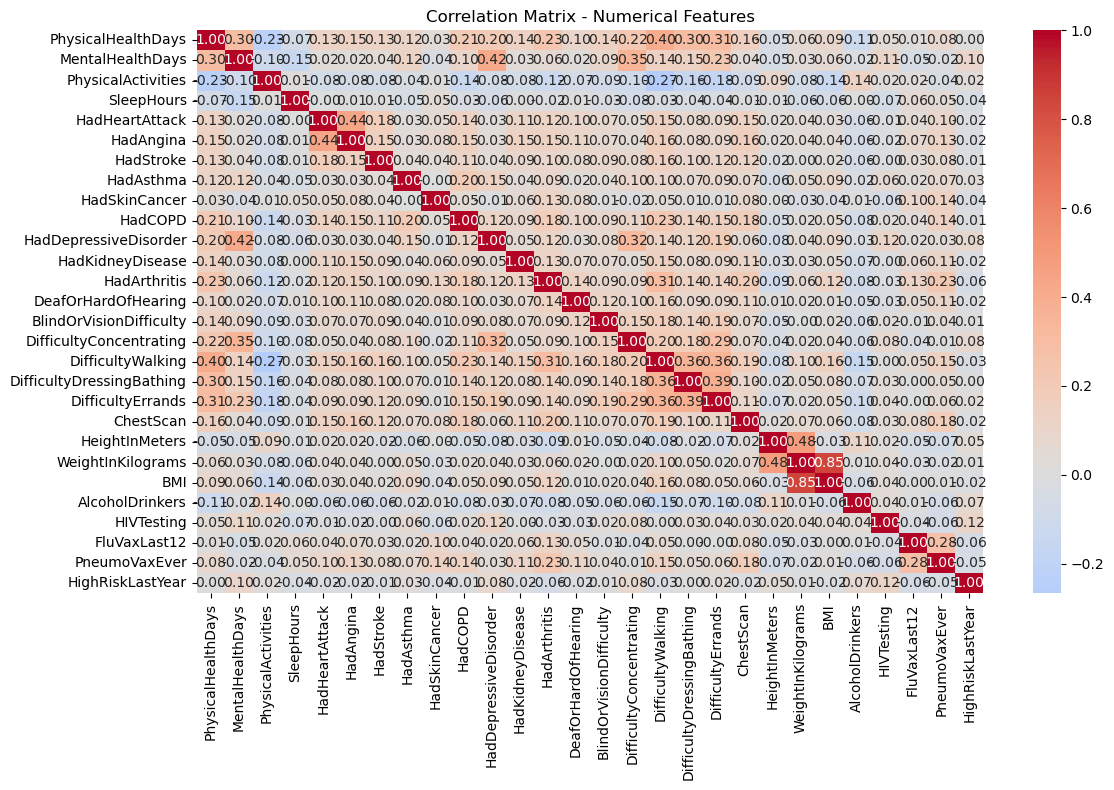

In [7]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

In [8]:
corr_with_target = corr_matrix['HadHeartAttack'].drop('HadHeartAttack').sort_values(key=abs, ascending=False)
corr_with_target

HadAngina                    0.444852
HadStroke                    0.180061
DifficultyWalking            0.151488
ChestScan                    0.148665
HadCOPD                      0.137621
PhysicalHealthDays           0.131366
HadArthritis                 0.119954
HadKidneyDisease             0.113513
PneumoVaxEver                0.099957
DeafOrHardOfHearing          0.095058
DifficultyErrands            0.085921
PhysicalActivities          -0.081283
DifficultyDressingBathing    0.079125
BlindOrVisionDifficulty      0.070036
AlcoholDrinkers             -0.064495
HadSkinCancer                0.052086
DifficultyConcentrating      0.046440
FluVaxLast12                 0.041063
WeightInKilograms            0.038607
BMI                          0.030382
HadAsthma                    0.025175
HadDepressiveDisorder        0.025161
MentalHealthDays             0.024196
HeightInMeters               0.022390
HighRiskLastYear            -0.017961
HIVTesting                  -0.013554
SleepHours  

The correlation analysis showed that HadAngina had the strongest positive correlation with heart attack occurrence **(r = 0.445)**, indicating that patients with angina are more likely to have had a heart attack. Other important positively correlated factors were HadStroke **(r = 0.180)**, DifficultyWalking **(r = 0.151)**, and ChestScan **(r = 0.149)**. On the other hand, PhysicalActivities had a negative correlation **(r = -0.081)**, suggesting that regular physical activity may reduce heart attack risk.

### 2. Chi-Square Test (for Categorical columns)

In [9]:
cat_cols = ['GeneralHealth', 'AgeCategory', 'Sex', 'SmokerStatus',
            'RemovedTeeth', 'LastCheckupTime', 'ECigaretteUsage',
            'RaceEthnicityCategory']

chi2_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['HadHeartAttack'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    chi2_results.append({'Feature': col, 'Chi2': round(chi2, 2), 'P-Value': round(p, 5), 'DOF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print(chi2_df)

                 Feature      Chi2  P-Value  DOF
0          GeneralHealth  15550.63      0.0    4
1            AgeCategory  13014.32      0.0   12
4           RemovedTeeth  11682.66      0.0    3
3           SmokerStatus   3471.01      0.0    3
2                    Sex   2054.71      0.0    1
5        LastCheckupTime   1906.33      0.0    3
7  RaceEthnicityCategory    386.09      0.0    4
6        ECigaretteUsage    173.70      0.0    3


The Chi-Square test revealed that several categorical variables had a statistically significant association with heart attack occurrence(p < 0.05 for all tested features). GeneralHealth showed the strongest association **(Chi² = 15550.63)**, followed by AgeCategory **(Chi² = 13014.32)** and RemovedTeeth **(Chi² = 11682.66)**. This indicates that poor general health, older age, and severe dental issues are strongly linked to higher heart attack risk.

### 3. Heart Attack Rate by Key Features


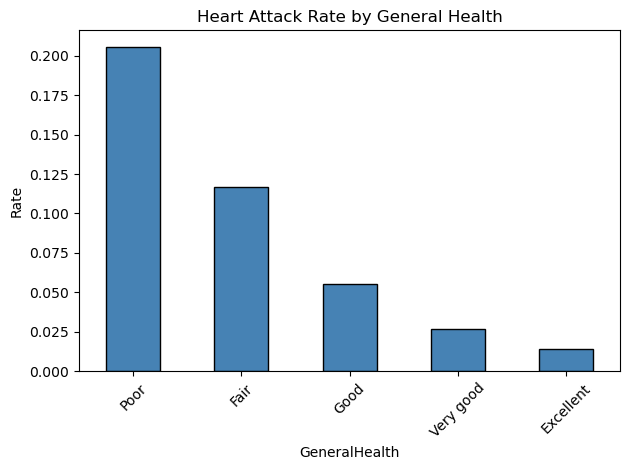

In [10]:
# Regarding GeneralHealth
ha_by_health = df.groupby('GeneralHealth')['HadHeartAttack'].mean().sort_values(ascending=False)
ha_by_health.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Heart Attack Rate by General Health')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

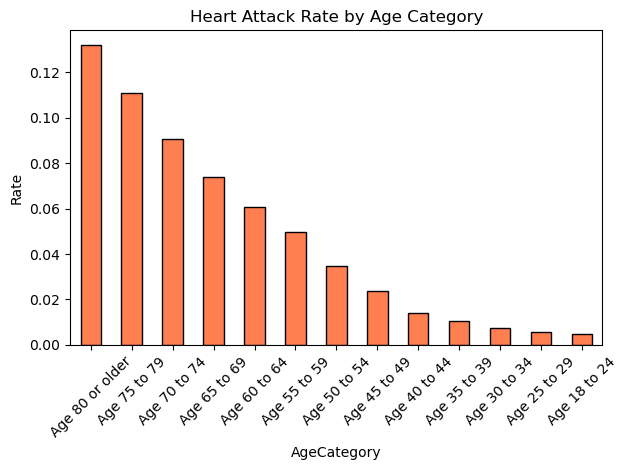

In [11]:
# Regarding AgeCategory
ha_by_age = df.groupby('AgeCategory')['HadHeartAttack'].mean().sort_values(ascending=False)
ha_by_age.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Heart Attack Rate by Age Category')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

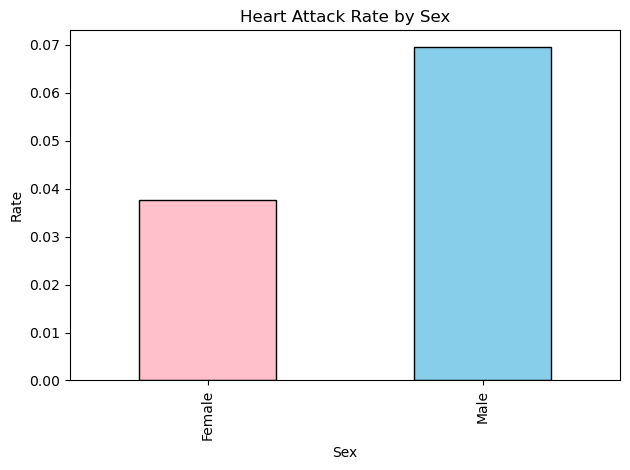

In [12]:
# Regarding Sex
ha_by_sex = df.groupby('Sex')['HadHeartAttack'].mean()
ha_by_sex.plot(kind='bar', color=['pink', 'skyblue'], edgecolor='black')
plt.title('Heart Attack Rate by Sex')
plt.ylabel('Rate')
plt.tight_layout()
plt.show()

The heart attack rate was noticeably higher among individuals who reported **poor general health**, compared to those with excellent or very good health. **Older age groups** also had a significantly higher heart attack rate than younger groups, showing that age is a major risk factor. In addition, **males** showed a higher heart attack rate than females, suggesting that gender may influence cardiovascular risk.

### 4. Feature Importance using Random Forest

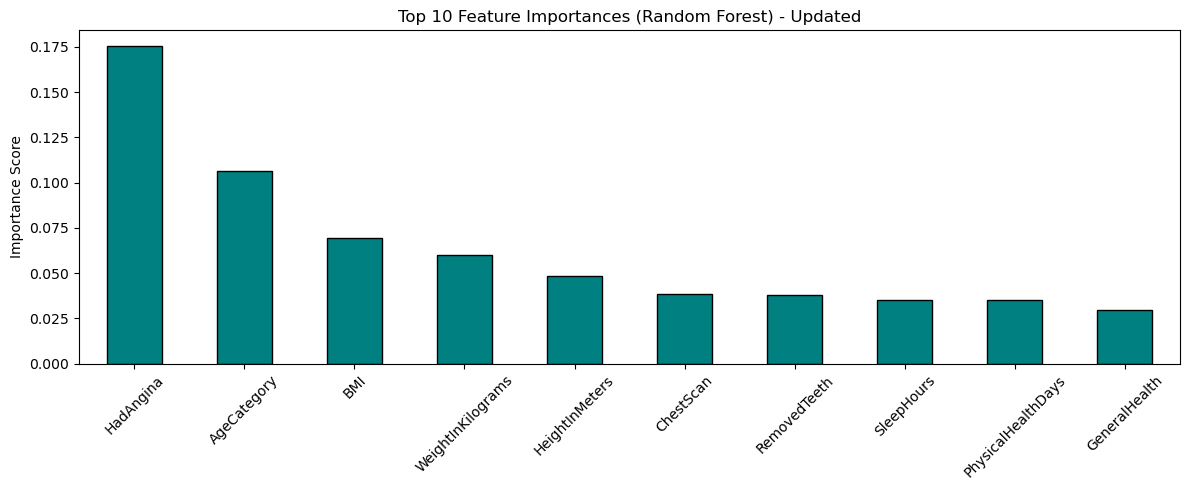

In [13]:
df_model = df.copy()

df_model = df_model.drop('State', axis=1)

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

df_model = df_model.dropna(subset=['HadHeartAttack'])

X = df_model.drop('HadHeartAttack', axis=1)
y = df_model['HadHeartAttack']

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances[:10].plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Feature Importances (Random Forest) - Updated')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print(importances[:10])

HadAngina             0.175350
AgeCategory           0.106561
BMI                   0.069209
WeightInKilograms     0.059728
HeightInMeters        0.048280
ChestScan             0.038453
RemovedTeeth          0.037805
SleepHours            0.035202
PhysicalHealthDays    0.034941
GeneralHealth         0.029718
dtype: float64


The Random Forest model identified **HadAngina** as the most important predictor of heart attack risk, with the highest importance score **(0.175)**. Other major contributing factors were **AgeCategory (0.107), BMI (0.069)**, and **WeightInKilograms (0.060)**. These results suggest that both existing heart-related conditions and physical health factors play a major role in predicting heart attack outcomes.

### 5. Statistical Summary for Numerical Features

In [15]:
# Comparing the averages between those who suffered a heart attack and those who didn't
num_features = ['BMI', 'SleepHours', 'PhysicalHealthDays', 'MentalHealthDays',
                'HeightInMeters', 'WeightInKilograms']

summary = df.groupby('HadHeartAttack')[num_features].mean().T
summary.columns = ['No Heart Attack', 'Had Heart Attack']
print(summary)

                    No Heart Attack  Had Heart Attack
BMI                        3.363486          3.390710
SleepHours                 7.009104          7.008567
PhysicalHealthDays         3.843796          8.762046
MentalHealthDays           4.158517          5.045236
HeightInMeters             1.702816          1.713107
WeightInKilograms         82.313523         85.558761


Patients who had experienced a heart attack reported significantly worse physical health. Their average **PhysicalHealthDays** was **8.76 days**, compared to **3.84 days** for those without heart attacks. They also had slightly higher **BMI (3.39 vs 3.36)** and higher average **weight (85.56 kg vs 82.31 kg)**, indicating that obesity-related factors may contribute to cardiovascular risk.

### 6. T-Test Insights

In [16]:
ttest_results = []
for col in num_features:
    group0 = df[df['HadHeartAttack'] == 0][col].dropna()
    group1 = df[df['HadHeartAttack'] == 1][col].dropna()
    t_stat, p_val = ttest_ind(group0, group1)
    ttest_results.append({'Feature': col, 'T-Statistic': round(t_stat, 3), 'P-Value': round(p_val, 5)})

print(pd.DataFrame(ttest_results).sort_values('T-Statistic'))

              Feature  T-Statistic  P-Value
2  PhysicalHealthDays      -84.242  0.00000
5   WeightInKilograms      -24.562  0.00000
0                 BMI      -19.323  0.00000
3    MentalHealthDays      -15.386  0.00000
4      HeightInMeters      -14.237  0.00000
1          SleepHours        0.057  0.95461


The T-test results showed statistically significant differences between heart attack and non-heart attack groups for most numerical features **(p < 0.05). PhysicalHealthDays** had the strongest difference **(t = -84.24)**, followed by **WeightInKilograms (t = -24.56)** and **BMI (t = -19.32)**. However, **SleepHours** showed no significant difference **(p = 0.955)**, suggesting that sleep duration alone may not be strongly associated with heart attack occurrence in this dataset.

# Physical Activities Distribution

This Donut Chart shows the distribution of physical activity levels among the participants in the dataset.  
- Each segment represents a different category of physical activity.  
- The percentages indicate the proportion of participants in each category.  
- The white circle in the center creates a "donut" effect for better visual appeal.

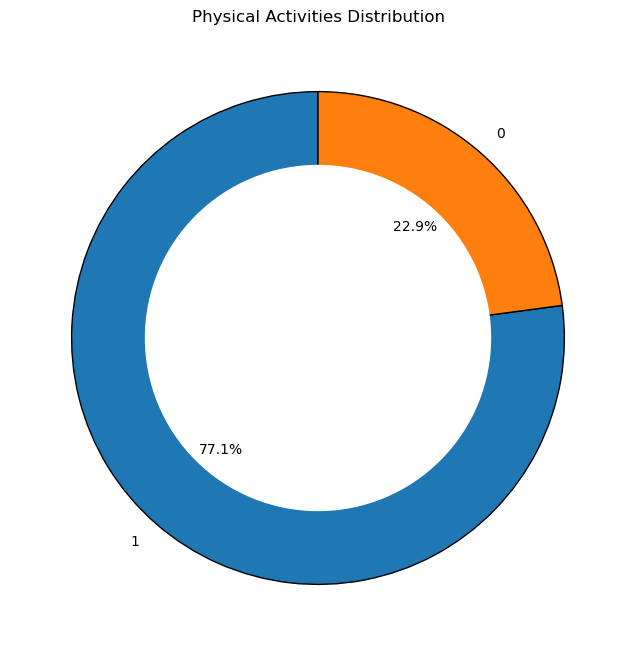

In [17]:
Physical_Activities = df['PhysicalActivities'].value_counts()

plt.figure(figsize=(12,8))
plt.pie(Physical_Activities,labels=Physical_Activities.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor': 'black'})
plt.gca().add_artist(plt.Circle((0,0),0.7, color='white'))
plt.title('Physical Activities Distribution')
plt.show()

# Health Metrics Correlation Heatmap

This heatmap shows the correlations between key health metrics:  
- Physical Health Days  
- Mental Health Days  
- Sleep Hours  
- BMI  

Darker colors indicate stronger correlations, helping to identify patterns and relationships among these variables.

Heatmap: Illustrating the relationship between physical health, mental health, sleep, and BMI


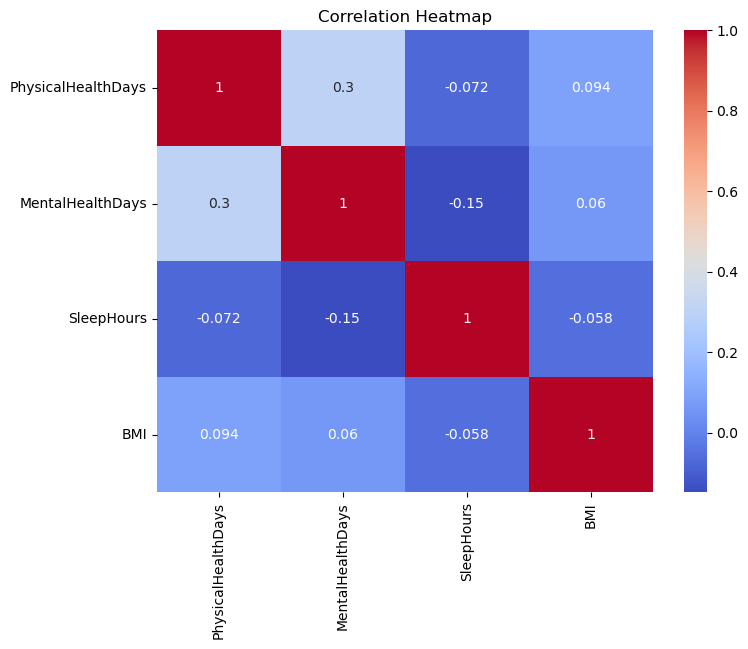

In [18]:
cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'BMI']
df_numeric = df[cols]
print("Heatmap: Illustrating the relationship between physical health, mental health, sleep, and BMI")

plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# General Health across Age Groups

This count plot shows the distribution of general health categories across different age groups.  
- Each bar represents the number of participants in a specific age group.  
- Different colors indicate different general health statuses.  
- Helps to identify how health varies with age.

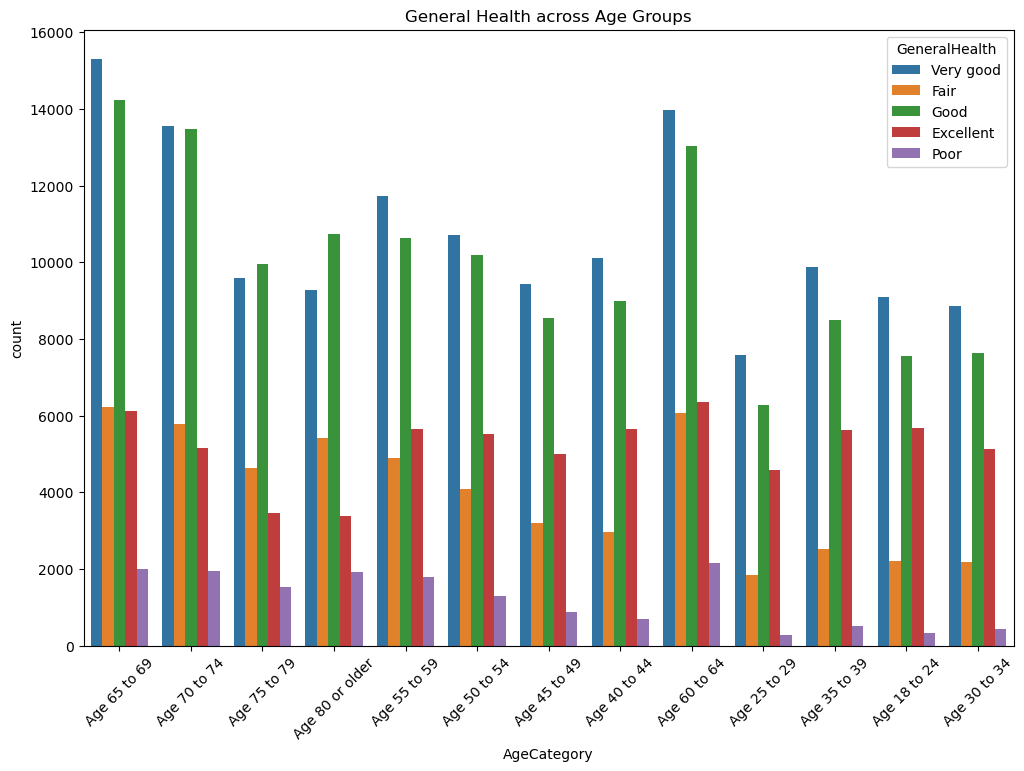

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(x='AgeCategory', hue='GeneralHealth', data=df)
plt.xticks(rotation=45)
plt.title("]]")
plt.show()

# Top 10 States with High-Risk Individuals Last Year

This bar chart shows the top 10 states with the highest number of high-risk individuals last year.  
- Each bar represents the count of high-risk participants in that state.  
- The color intensity reflects the number of individuals, with darker red indicating higher counts.  
- Useful for identifying states with greater health risks for targeted interventions.

In [20]:
High_Risk_LastYear_State = df[df['HighRiskLastYear'] == 1]['State']
top_states = High_Risk_LastYear_State.value_counts().head(10).reset_index()
top_states.columns = ['State', 'Count']

fig = px.bar(top_states,x='State',y='Count',title='Top 10 States with High-Risk Individuals Last Year',color='Count',color_continuous_scale='Reds')
fig.show()

# Top 10 States with Low-Risk Individuals Last Year

This bar chart shows the top 10 states with the highest number of low-risk individuals last year.  
- Each bar represents the count of low-risk participants in that state.  
- The color intensity reflects the number of individuals, with darker blue indicating higher counts.  
- Useful for comparing healthier populations across states.

In [21]:
Low_Risk_LastYear_State = df[df['HighRiskLastYear'] == 0]['State']
low_states = Low_Risk_LastYear_State.value_counts().head(10).reset_index()
low_states.columns = ['State', 'Count']

fig = px.bar(low_states,x='State',y='Count',title='Top 10 States with Low-Risk Individuals Last Year',color='Count',color_continuous_scale='Blues',text='Count')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='State',yaxis_title='Number of Low-Risk Individuals',showlegend=False)
fig.show()

# Smoking vs Physical Health

This box plot compares the number of physical health days between smokers and non-smokers.  
- Each box shows the distribution of physical health days for each smoking status.  
- Helps to identify the impact of smoking on physical health.

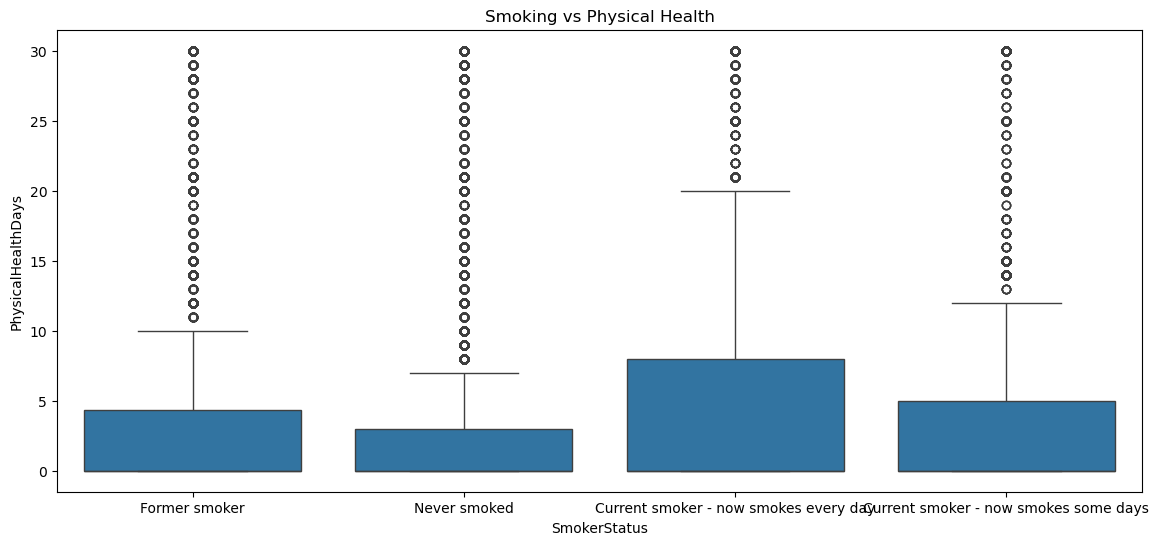

In [22]:
plt.figure(figsize=(14,6))
sns.boxplot(x='SmokerStatus', y='PhysicalHealthDays', data=df)
plt.title("Smoking vs Physical Health")
plt.show()

### E-Cigarette Usage Distribution

This bar chart illustrates the distribution of different e-cigarette usage categories within the dataset. The visualization helps identify the most common usage patterns and compare the frequency of each group.

By analyzing the distribution, we can better understand the prevalence of e-cigarette consumption and detect whether the dataset is balanced across usage categories or dominated by specific groups.

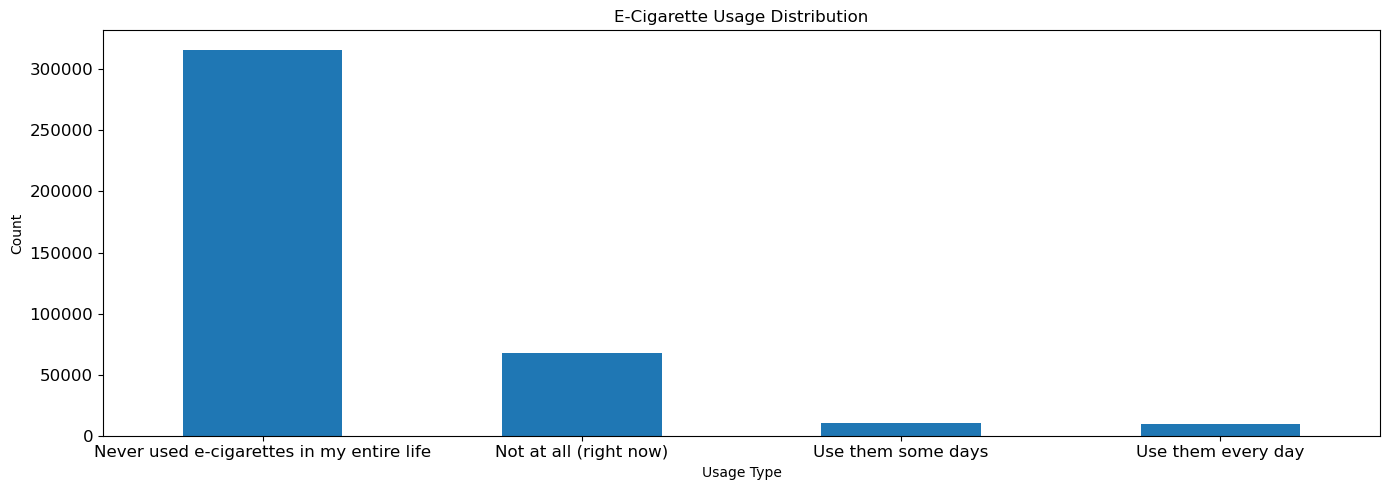

In [23]:
plt.figure(figsize=(14,5))
E_cigarette = df['ECigaretteUsage'].value_counts().plot(kind='bar')

plt.title("E-Cigarette Usage Distribution", color='black')
plt.xlabel('Usage Type', color='black')
plt.ylabel('Count', color='black')
plt.xticks(color='black', fontsize=12,rotation=0)
plt.yticks(color='black', fontsize=12)
plt.tight_layout()
plt.show()

# Alcohol Drinkers Distribution

This pie chart shows the percentage of participants who consume alcohol versus those who do not.  
- Each slice represents a category of alcohol consumption.  
- Percentages inside the slices indicate the proportion of each group.  
- Helps to quickly understand alcohol consumption patterns in the population.

In [24]:
Alcohol = df['AlcoholDrinkers'].value_counts().reset_index()
Alcohol.columns = ['AlcoholDrinkers', 'Count']

fig = px.pie(Alcohol,names='AlcoholDrinkers',values='Count',color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title='Alcohol Drinkers Distribution',title_font_size=18)
fig.update_traces(textposition='inside', textinfo='percent+label')

In [25]:
from google.colab import files
from IPython.display import Image

uploaded = files.upload()


Image('Screenshot 2025-10-21 140637.png')

ModuleNotFoundError: No module named 'google.colab'